# 03 Análisis exploratorio espacial y métricas

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Este notebook cubre el **análisis exploratorio espacial** (paso 7 del plan) y, más adelante, las métricas globales y locales (paso 8). Trabaja sin red, sobre el grafo limpio de `01` y los POI de `02b`.

**Regla de normalización:** toda métrica que dependa de la escala se expresa por km² del distrito (o por nodo). Los nodos y aristas del buffer (`Fuera (buffer)`) se usan solo para el ruteo y **no entran** en las métricas por distrito.

## 1. Carga y preparación

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import entropy
from shapely.geometry import box

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg
from src import mapas

np.random.seed(cfg.SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
DISTRITOS = cfg.DISTRICT_LABELS
COLOR_D = {"Miraflores": "#1f77b4", "San Juan de Miraflores": "#e08a1e"}

G = ox.load_graphml(cfg.DATA_INTERIM / "walk_graph_clean.graphml")
limites_utm = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)
poi = pd.read_csv(cfg.DATA_PROCESSED / "poi_snap.csv")
poi = poi[poi["snap_valido"]].copy()

nodos, aristas = ox.graph_to_gdfs(G)
aristas = aristas.reset_index()
aristas["tiene_escalera"] = aristas["tiene_escalera"].astype(str).eq("True")

# Distrito de cada arista: el del polígono que contiene su punto medio
medio = gpd.GeoDataFrame(geometry=aristas.geometry.interpolate(0.5, normalized=True), crs=aristas.crs)
j = gpd.sjoin(medio, limites_utm[["distrito", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated(keep="first")]
aristas["distrito"] = j["distrito"].fillna("Fuera (buffer)")

area_km2 = limites_utm.set_index("distrito").geometry.area / 1e6
print(f"Nodos: {len(nodos):,} | aristas dirigidas: {len(aristas):,}")
print("Área (km²):", area_km2.round(2).to_dict())
pd.DataFrame({"nodos": nodos["distrito"].value_counts(), "aristas dirigidas": aristas["distrito"].value_counts()})

Nodos: 17,265 | aristas dirigidas: 51,216
Área (km²): {'Miraflores': 9.45, 'San Juan de Miraflores': 22.06}


,nodos,aristas dirigidas
distrito,,
San Juan de Miraflores,9127,27746
Fuera (buffer),4297,12034
Miraflores,3841,11436


## 2. Vista general

Red peatonal por tipo de vía, límites distritales y POI de equipamiento.

Los tipos de `highway_main` se agrupan en cuatro clases: **arterial** (trunk, primary, secondary, tertiary y sus enlaces), **local** (residential, living_street, unclassified, service), **peatonal** (footway, pedestrian, path, corridor, track, bridleway) y **escaleras** (steps, ladder).

In [2]:
GRUPOS = {
    "Arterial": ["trunk", "trunk_link", "primary", "primary_link", "secondary", "secondary_link", "tertiary", "tertiary_link"],
    "Local": ["residential", "living_street", "unclassified", "service"],
    "Peatonal": ["footway", "pedestrian", "path", "corridor", "track", "bridleway", "busway"],
    "Escaleras": ["steps", "ladder"],
}
a_grupo = {t: g for g, ts in GRUPOS.items() for t in ts}
aristas["grupo_via"] = aristas["highway_main"].map(a_grupo).fillna("Otro")
print("Aristas sin grupo (Otro):", (aristas["grupo_via"] == "Otro").sum())
aristas.groupby("grupo_via").agg(aristas=("length", "size"), km=("length", lambda s: s.sum() / 2 / 1000)).round(1)

Aristas sin grupo (Otro): 0


,aristas,km
grupo_via,,
Arterial,8140,231.5
Escaleras,1988,42.8
Local,24638,669.6
Peatonal,16450,248.9


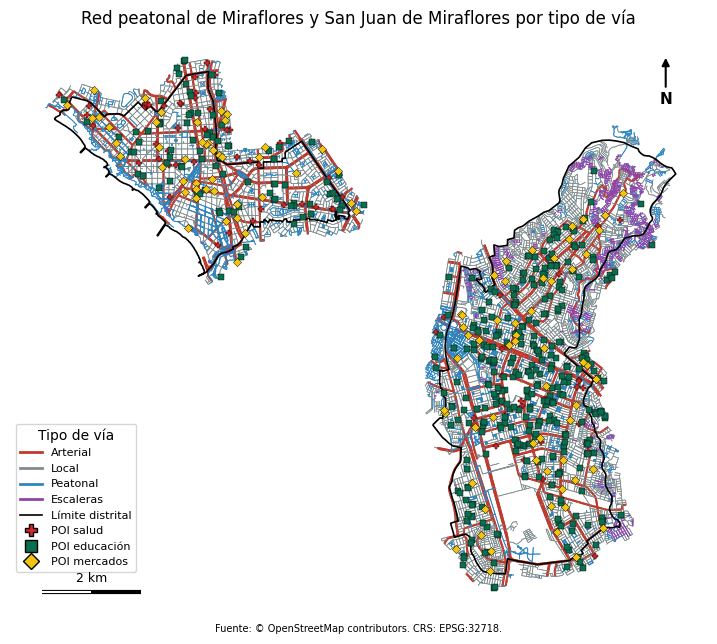

In [3]:
ESTILO = {"Arterial": ("#c0392b", 1.4), "Local": ("#7f8c8d", 0.5), "Peatonal": ("#2e86c1", 0.6), "Escaleras": ("#8e44ad", 0.8)}
fig, ax = plt.subplots(figsize=(9, 9))
for grupo, (color, lw) in ESTILO.items():
    aristas[aristas["grupo_via"] == grupo].plot(ax=ax, color=color, linewidth=lw)
limites_utm.boundary.plot(ax=ax, color="k", lw=1.2)
for capa, (color, marca) in {"salud": ("#d62728", "P"), "educacion": ("#0b6e4f", "s"), "mercados": ("#f1c40f", "D")}.items():
    p = gpd.GeoDataFrame(poi[poi["capa"] == capa], geometry=gpd.points_from_xy(poi.loc[poi["capa"] == capa, "x"], poi.loc[poi["capa"] == capa, "y"]), crs=cfg.CRS_METRIC)
    p.plot(ax=ax, color=color, marker=marca, markersize=18, edgecolor="k", linewidth=0.3, zorder=5)
ax.set_axis_off()
mapas.escala_y_norte(ax, 2000)
leyenda = [Line2D([0], [0], color=c, lw=2, label=g) for g, (c, _) in ESTILO.items()]
leyenda += [Line2D([0], [0], color="k", lw=1.2, label="Límite distrital")]
leyenda += [Line2D([0], [0], marker=m, color="w", markerfacecolor=c, markeredgecolor="k", markersize=8, label=f"POI {n}")
            for n, (c, m) in {"salud": ("#d62728", "P"), "educación": ("#0b6e4f", "s"), "mercados": ("#f1c40f", "D")}.items()]
ax.legend(handles=leyenda, loc="lower left", bbox_to_anchor=(0.0, 0.07), fontsize=8, frameon=True, title="Tipo de vía")
ax.set_title("Red peatonal de Miraflores y San Juan de Miraflores por tipo de vía")
ax.text(0.5, -0.01, "Fuente: © OpenStreetMap contributors. CRS: EPSG:32718.", transform=ax.transAxes, ha="center", va="top", fontsize=7)
mapas.guardar(fig, cfg.FIG_MAPS / "eda_01_red_por_tipo_via.png")
plt.show()

## 3. Densidades y estructura (normalizadas por área)

Para cada distrito se usan solo sus nodos y las aristas cuyo punto medio cae dentro de él.

- **Densidad de intersecciones:** nodos con `street_count ≥ 3` por km².
- **Calles sin salida:** nodos con `street_count = 1`.
- **Longitud de vía:** km de calle (cada calle cuenta una vez; el grafo dirigido las tiene en ambos sentidos).
- Se advierte que el área del distrito incluye terreno sin urbanizar (cerros, parques), que baja las densidades.

In [4]:
filas = {}
for d in DISTRITOS:
    n = nodos[nodos["distrito"] == d]
    e = aristas[aristas["distrito"] == d]
    A = area_km2[d]
    km = e["length"].sum() / 2 / 1000
    filas[d] = {
        "área (km²)": A,
        "nodos": len(n),
        "nodos / km²": len(n) / A,
        "intersecciones (grado ≥ 3)": int((n["street_count"] >= 3).sum()),
        "intersecciones / km²": (n["street_count"] >= 3).sum() / A,
        "% calles sin salida (grado 1)": (n["street_count"] == 1).mean() * 100,
        "longitud de vía (km)": km,
        "km de vía / km²": km / A,
        "longitud media de arista (m)": e["length"].mean(),
        "grado medio (street_count)": n["street_count"].mean(),
    }
tabla_dens = pd.DataFrame(filas)
tabla_dens.round(2)

,Miraflores,San Juan de Miraflores
área (km²),9.45,22.06
nodos,3841.00,9127.00
nodos / km²,406.62,413.64
intersecciones (grado ≥ 3),3217.00,8310.00
intersecciones / km²,340.56,376.62
% calles sin salida (grado 1),14.61,8.38
longitud de vía (km),269.60,644.28
km de vía / km²,28.54,29.20
longitud media de arista (m),47.15,46.44
grado medio (street_count),2.98,3.05


### Composición de la red por tipo de vía

Proporción de la **longitud** de vía por grupo (no del número de aristas, para no sobrevalorar los tramos cortos), y proporción de longitud con escaleras.

grupo_via               Arterial  Local  Peatonal  Escaleras  % con algún tramo de escalera
distrito                                                                                   
Miraflores                  25.8   46.9      27.1        0.2                            1.1
San Juan de Miraflores      17.6   61.2      16.3        4.9                            5.8


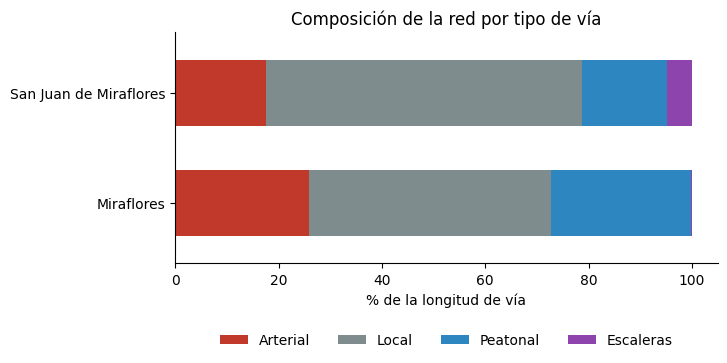

In [5]:
comp = (aristas[aristas["distrito"].isin(DISTRITOS)].groupby(["distrito", "grupo_via"])["length"].sum().unstack(fill_value=0))
comp_pct = comp.div(comp.sum(axis=1), axis=0).mul(100).loc[DISTRITOS, list(GRUPOS)]
esc = aristas[aristas["distrito"].isin(DISTRITOS)].groupby("distrito").apply(lambda g: g.loc[g["tiene_escalera"], "length"].sum() / g["length"].sum() * 100, include_groups=False)
comp_pct["% con algún tramo de escalera"] = esc.loc[DISTRITOS]
print(comp_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 3))
comp_pct[list(GRUPOS)].plot.barh(stacked=True, ax=ax, color=[ESTILO[g][0] for g in GRUPOS], width=0.6)
ax.set_xlabel("% de la longitud de vía")
ax.set_ylabel("")
ax.set_title("Composición de la red por tipo de vía")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
mapas.guardar(fig, cfg.FIG_PLOTS / "eda_04_composicion_vias.png")
plt.show()

### Distribución de la longitud de arista

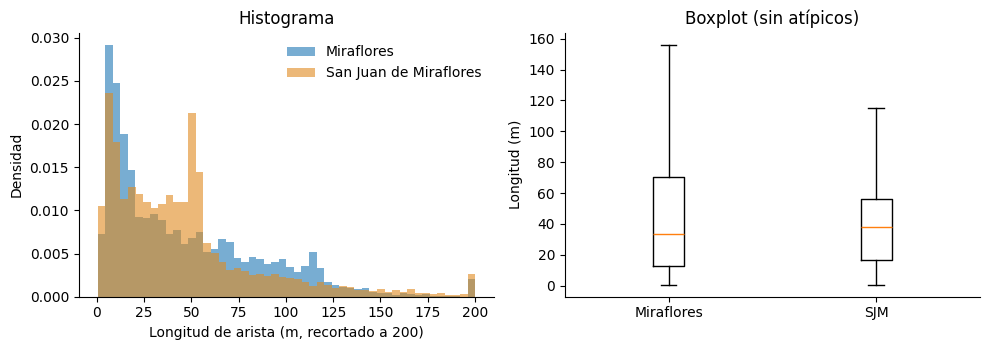

,count,mean,std,min,25%,50%,75%,max
distrito,,,,,,,,
Miraflores,11436.0,47.1,44.8,0.5,12.8,33.5,70.5,562.9
San Juan de Miraflores,27746.0,46.4,44.0,0.6,16.3,38.3,55.9,737.7


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
for d in DISTRITOS:
    s = aristas.loc[aristas["distrito"] == d, "length"]
    axs[0].hist(s.clip(upper=200), bins=50, alpha=0.6, color=COLOR_D[d], label=d, density=True)
axs[0].set(xlabel="Longitud de arista (m, recortado a 200)", ylabel="Densidad", title="Histograma")
axs[0].legend(frameon=False)
axs[1].boxplot([aristas.loc[aristas["distrito"] == d, "length"] for d in DISTRITOS], tick_labels=["Miraflores", "SJM"], showfliers=False)
axs[1].set(ylabel="Longitud (m)", title="Boxplot (sin atípicos)")
fig.tight_layout()
mapas.guardar(fig, cfg.FIG_PLOTS / "eda_03_longitudes.png")
plt.show()
aristas[aristas["distrito"].isin(DISTRITOS)].groupby("distrito")["length"].describe().loc[DISTRITOS].round(1)

## 4. Orientación de las calles

El rumbo de cada arista se calcula desde las coordenadas proyectadas de sus extremos (0° = norte). Se usan los dos sentidos de cada calle (el histograma es simétrico), 36 clases de 10° centradas en 0°, 10°… y ponderadas por longitud.

- **Entropía de orientación** *H* (Shannon, en nats): 0 si todas las calles tienen el mismo rumbo; ln 36 ≈ 3.58 si son uniformes; ln 4 ≈ 1.39 en una cuadrícula perfecta.
- **Índice de orden** φ = 1 − ((*H* − ln 4) / (ln 36 − ln 4))²: 1 es una cuadrícula perfecta y 0 un patrón uniforme.

In [7]:
xy = nodos[["x", "y"]]
u_xy = xy.loc[aristas["u"]].to_numpy()
v_xy = xy.loc[aristas["v"]].to_numpy()
aristas["rumbo"] = np.degrees(np.arctan2(v_xy[:, 0] - u_xy[:, 0], v_xy[:, 1] - u_xy[:, 1])) % 360

BINS = 36
def hist_orient(g):
    b = np.concatenate([g["rumbo"].to_numpy(), (g["rumbo"].to_numpy() + 180) % 360])
    w = np.concatenate([g["length"].to_numpy()] * 2)
    ancho = 360 / BINS
    h, _ = np.histogram((b + ancho / 2) % 360, bins=BINS, range=(0, 360), weights=w)
    return h

H_GRID, H_MAX = np.log(4), np.log(BINS)
orient, filas = {}, {}
for d in DISTRITOS:
    h = hist_orient(aristas[aristas["distrito"] == d])
    orient[d] = h
    H = entropy(h)
    filas[d] = {"entropía H (nats)": H, "índice de orden φ": 1 - ((H - H_GRID) / (H_MAX - H_GRID)) ** 2}
tabla_orient = pd.DataFrame(filas).T
print(f"Referencias: cuadrícula perfecta H = {H_GRID:.2f}, uniforme H = {H_MAX:.2f}")
tabla_orient.round(3)

Referencias: cuadrícula perfecta H = 1.39, uniforme H = 3.58


,entropía H (nats),índice de orden φ
Miraflores,3.413,0.149
San Juan de Miraflores,3.522,0.055


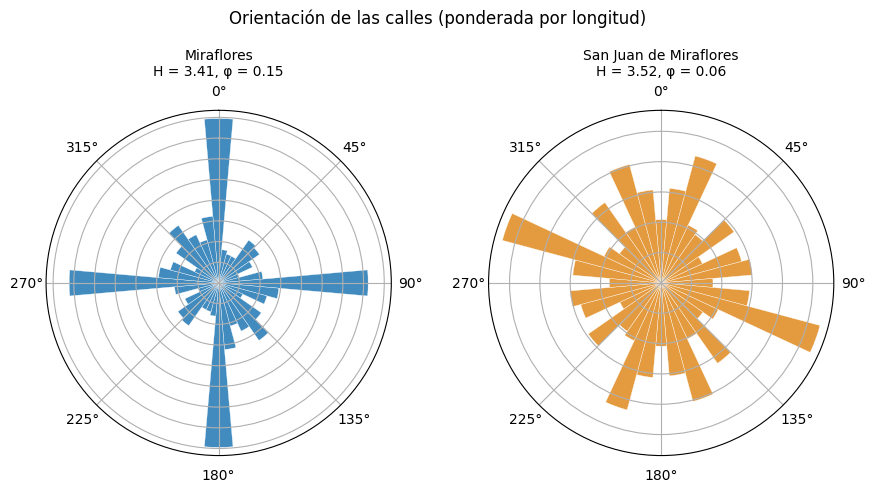

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.6), subplot_kw={"projection": "polar"})
theta = np.deg2rad(np.arange(BINS) * 360 / BINS)
for ax, d in zip(axs, DISTRITOS):
    h = orient[d] / orient[d].sum()
    ax.bar(theta, h, width=np.deg2rad(360 / BINS), color=COLOR_D[d], alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.set_title(f"{d}\nH = {tabla_orient.loc[d, 'entropía H (nats)']:.2f}, φ = {tabla_orient.loc[d, 'índice de orden φ']:.2f}", fontsize=10)
fig.suptitle("Orientación de las calles (ponderada por longitud)", y=1.02)
fig.tight_layout()
mapas.guardar(fig, cfg.FIG_PLOTS / "eda_05_orientacion.png")
plt.show()

## 5. Distribución de los POI

Conteo de POI válidos por capa en cada distrito y densidad por km². Los POI del buffer no entran: pertenecen a distritos vecinos.

In [9]:
p = poi[poi["zona"].isin(DISTRITOS)]
cuenta = p.groupby(["zona", "capa"]).size().unstack(fill_value=0).loc[DISTRITOS]
dens = cuenta.div(area_km2.loc[DISTRITOS], axis=0)
nodos_poi = p.groupby(["zona", "capa"])["nodo_osmid"].nunique().unstack(fill_value=0).loc[DISTRITOS]
tabla_poi = pd.concat({"POI": cuenta, "POI / km²": dens.round(2), "nodos distintos": nodos_poi}, axis=1)
tabla_poi

POI                POI / km²                 \
capa                   educacion mercados salud educacion mercados salud   
zona                                                                       
Miraflores                    63       30    30      6.67     3.18  3.18   
San Juan de Miraflores       284       51    24     12.87     2.31  1.09   

                       nodos distintos                 
capa                         educacion mercados salud  
zona                                                   
Miraflores                          59       30    29  
San Juan de Miraflores             250       50    23

## 6. Calidad de los datos: dónde no hay red

Se divide el territorio de cada distrito en celdas de 100 m y se mide qué proporción **no es cruzada por ninguna arista**. Una proporción alta puede deberse a terreno no urbanizado (cerros, parques, zonas militares) o a vacíos de OpenStreetMap. Es relevante para el porcentaje de **superficie** cubierta en el Hito 2.

In [10]:
def grilla(lado):
    xmin, ymin, xmax, ymax = limites_utm.total_bounds
    xs, ys = np.arange(xmin, xmax, lado), np.arange(ymin, ymax, lado)
    celdas = gpd.GeoDataFrame(geometry=[box(x, y, x + lado, y + lado) for x in xs for y in ys], crs=cfg.CRS_METRIC)
    cj = gpd.sjoin(gpd.GeoDataFrame(geometry=celdas.geometry.centroid, crs=cfg.CRS_METRIC),
                   limites_utm[["distrito", "geometry"]], how="inner", predicate="within")
    return celdas.loc[cj.index].assign(distrito=cj["distrito"])

c100 = grilla(100)
toca = gpd.sjoin(c100[["geometry"]], aristas[["geometry"]], predicate="intersects").index.unique()
c100["con_red"] = c100.index.isin(toca)
sin_red = c100.groupby("distrito")["con_red"].agg(celdas="size", pct_sin_red=lambda s: (~s).mean() * 100).loc[DISTRITOS]
sin_red.round(1)

,celdas,pct_sin_red
distrito,,
Miraflores,944,3.5
San Juan de Miraflores,2204,6.8


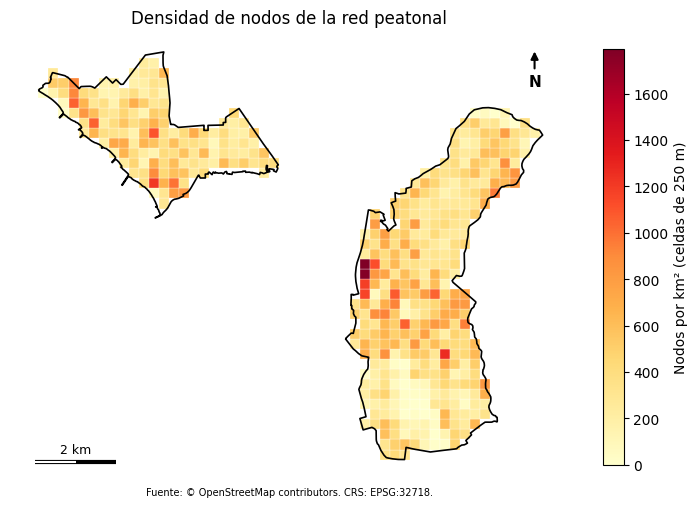

,count,mean,std,min,25%,50%,75%,max
distrito,,,,,,,,
Miraflores,149.0,404.0,228.0,0.0,240.0,352.0,512.0,1216.0
San Juan de Miraflores,353.0,408.0,258.0,0.0,240.0,368.0,528.0,1792.0


In [11]:
c250 = grilla(250)
lado_km2 = (250 / 1000) ** 2
cnt = gpd.sjoin(nodos[["geometry"]], c250[["geometry"]], predicate="within").groupby("index_right").size()
c250["nodos_km2"] = c250.index.map(cnt).to_series(index=c250.index).fillna(0).to_numpy() / lado_km2

fig, ax = plt.subplots(figsize=(9, 9))
c250.plot(ax=ax, column="nodos_km2", cmap="YlOrRd", legend=True, edgecolor="white", linewidth=0.2,
          legend_kwds={"label": "Nodos por km² (celdas de 250 m)", "shrink": 0.6})
limites_utm.boundary.plot(ax=ax, color="k", lw=1.2)
ax.set_axis_off()
mapas.escala_y_norte(ax, 2000)
ax.set_title("Densidad de nodos de la red peatonal")
ax.text(0.5, -0.01, "Fuente: © OpenStreetMap contributors. CRS: EPSG:32718.", transform=ax.transAxes, ha="center", va="top", fontsize=7)
mapas.guardar(fig, cfg.FIG_MAPS / "eda_02_densidad_nodos.png")
plt.show()
c250.groupby("distrito")["nodos_km2"].describe().loc[DISTRITOS].round(0)

## 7. Comparación Miraflores vs San Juan de Miraflores

Resumen de las métricas normalizadas por área.

In [12]:
resumen = pd.concat([
    tabla_dens.loc[["nodos / km²", "intersecciones / km²", "km de vía / km²", "longitud media de arista (m)", "% calles sin salida (grado 1)"]],
    comp_pct.T.loc[["Arterial", "Local", "Peatonal", "Escaleras", "% con algún tramo de escalera"]].rename(lambda s: f"% longitud {s.lower()}" if s in GRUPOS else s),
    tabla_orient.T,
    cuenta.T.div(area_km2.loc[DISTRITOS], axis=1).rename(lambda s: f"POI {s} / km²"),
    sin_red[["pct_sin_red"]].T.rename(index={"pct_sin_red": "% del área sin red (celdas de 100 m)"}),
])
resumen.round(2)

,Miraflores,San Juan de Miraflores
nodos / km²,406.62,413.64
intersecciones / km²,340.56,376.62
km de vía / km²,28.54,29.20
longitud media de arista (m),47.15,46.44
% calles sin salida (grado 1),14.61,8.38
% longitud arterial,25.84,17.60
% longitud local,46.94,61.20
% longitud peatonal,27.06,16.35
% longitud escaleras,0.16,4.85
% con algún tramo de escalera,1.06,5.76


In [13]:
resumen.round(3).to_csv(cfg.DATA_PROCESSED / "eda_comparacion_distritos.csv")
print("Guardado:", cfg.DATA_PROCESSED / "eda_comparacion_distritos.csv")

Guardado: D:\TP-TF_Complex_Networks\data\processed\eda_comparacion_distritos.csv


### Hallazgos del análisis exploratorio (paso 7)

1. **Densidad de red casi igual en ambos distritos:** 407 vs 414 nodos/km² y 28.5 vs 29.2 km de vía/km². La densidad de intersecciones es algo mayor en SJM (377 vs 341 por km²). Con densidades tan parecidas, las diferencias de accesibilidad vendrán sobre todo de **dónde está el equipamiento** y de la forma de la red, no de cuánta red hay.
2. **Composición distinta:** Miraflores tiene más vía arterial (25.8 % de la longitud frente a 17.6 %) y más vía peatonal (27.1 % frente a 16.3 %); SJM es más local (61.2 % frente a 46.9 %).
3. **Escaleras:** 4.9 % de la longitud de SJM son escaleras (5.8 % de la longitud tiene algún tramo de escalera) frente a 0.2 % en Miraflores. Es un indicador de relieve y de posible sobreestimación de la accesibilidad al usar velocidad constante (limitación a declarar).
4. **Orientación:** Miraflores muestra cuatro picos claros en las direcciones N–S y E–O (H = 3.41, φ = 0.15), propios de una cuadrícula; SJM no tiene dirección dominante (H = 3.52, φ = 0.06, casi uniforme), coherente con trazado adaptado a laderas. Los valores de φ son bajos en ambos; una posible causa (por verificar, p. ej. repitiendo el cálculo solo con vías vehiculares) es que la red peatonal incluye pasajes y senderos en todas las direcciones.
5. **Calles sin salida:** 14.6 % de los nodos de Miraflores frente a 8.4 % en SJM. Está por aclarar si se debe a pasajes peatonales o a terminaciones por el borde del grafo.
6. **Equipamiento:** SJM tiene casi el doble de colegios por km² (12.9 vs 6.7), pero Miraflores tiene más densidad de salud (3.2 vs 1.1 por km²) y de mercados (3.2 vs 2.3). La densidad por área no es lo mismo que acceso por habitante: sin población no se puede afirmar quién está mejor servido (Hito 2).
7. **Cobertura territorial de la red:** el 3.5 % del área de Miraflores y el 6.8 % de la de SJM no es cruzada por ninguna arista (celdas de 100 m). Es el terreno sin urbanizar o con vacíos en OSM, y debe tenerse en cuenta al calcular el % de **superficie** cubierta por las isócronas.
8. **Mapa de densidad:** la mayor concentración de nodos está en una zona del oeste de SJM (hasta ≈ 1 800 nodos/km² en celdas de 250 m); el centro-sur de SJM es el de menor densidad.

**Limitación de la normalización:** las densidades usan el área total del distrito, que incluye cerros, parques y terreno sin urbanizar; las densidades sobre el área urbanizada serían mayores, sobre todo en SJM.